# Forecasts and their PITs

Following Gneiting, Balabdaoui and Raftery (2007, *J. R. Statist. Soc. B*, **69**, 243–268), nature draws $x_t \sim G_t$ and the forecaster issues a predictive CDF $F_t$. The **probability integral transform (PIT)** is

$$p_t = F_t(x_t).$$

If $F_t = G_t$ (the *ideal forecaster*), then $p_t \sim \text{Uniform}(0,1)$.

> *"Visual inspection of a PIT or rank histogram can provide hints to the reasons for forecast deficiency. Hump-shaped histograms indicate overdispersed predictive distributions with prediction intervals that are too wide on average. U-shaped histograms often correspond to predictive distributions that are too narrow. Triangle-shaped histograms are seen when the predictive distributions are biased."* — Gneiting et al. (2007), §3.1

Below we draw a single sample $\{x_t\}$ from a fixed $G = \mathcal{N}(10, 5)$ and compute $p_t = F(x_t)$ under five candidate forecasts $F$, each illustrating one of these failure modes.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

sns.set(style="whitegrid")
rng = np.random.default_rng(544)

## Setup: nature $G$, sample $\{x_t\}$, candidate forecasts $F$

In [8]:
# Nature: G = N(mu_G, sigma_G). Draw T outcomes x_t ~ G.
mu_G, sigma_G = 10, 5
T = 1000
x = rng.normal(mu_G, sigma_G, T)

# Candidate forecasts F (each is a normal CDF with given mean, sd).
forecasts = {
    "F = G  (ideal)":            (mu_G,     sigma_G),
    "G: overdispersed (too wide)":   (mu_G,     2 * sigma_G),
    "H: underdispersed (too narrow)":(mu_G,     sigma_G / 2.5),
    "K: biased low":                 (mu_G - 5, sigma_G),
    "L: biased high":                (mu_G + 5, sigma_G),
}

# PIT under each forecast: p_t = F(x_t)
pits = {label: norm.cdf(x, loc=m, scale=s) for label, (m, s) in forecasts.items()}

## Realized data: histogram of $\{x_t\}$

For reference, the data live in $\mathbb{R}$ and look bell-shaped. The PIT lives in $[0,1]$ and is uniform if $F = G$.

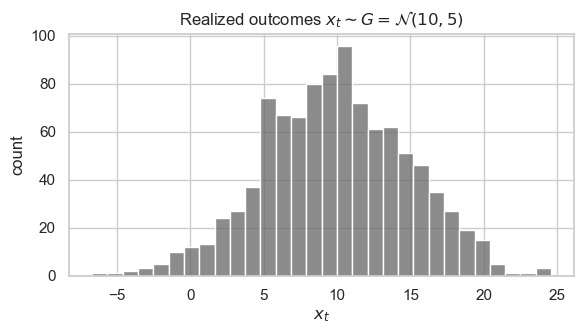

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(x, bins=30, color="0.4", ax=ax)
ax.set(title=r"Realized outcomes $x_t \sim G = \mathcal{N}(10, 5)$",
       xlabel=r"$x_t$", ylabel="count")
plt.tight_layout()
plt.show()

## PIT histograms

Compare each panel against the dashed uniform reference. Map shapes to deficiencies as in Gneiting et al. (2007):

- **Flat** → ideal (or at least probabilistically calibrated)
- **Hump** → predictive too wide (overdispersed)
- **U** → predictive too narrow (underdispersed)
- **Triangle / monotone** → biased

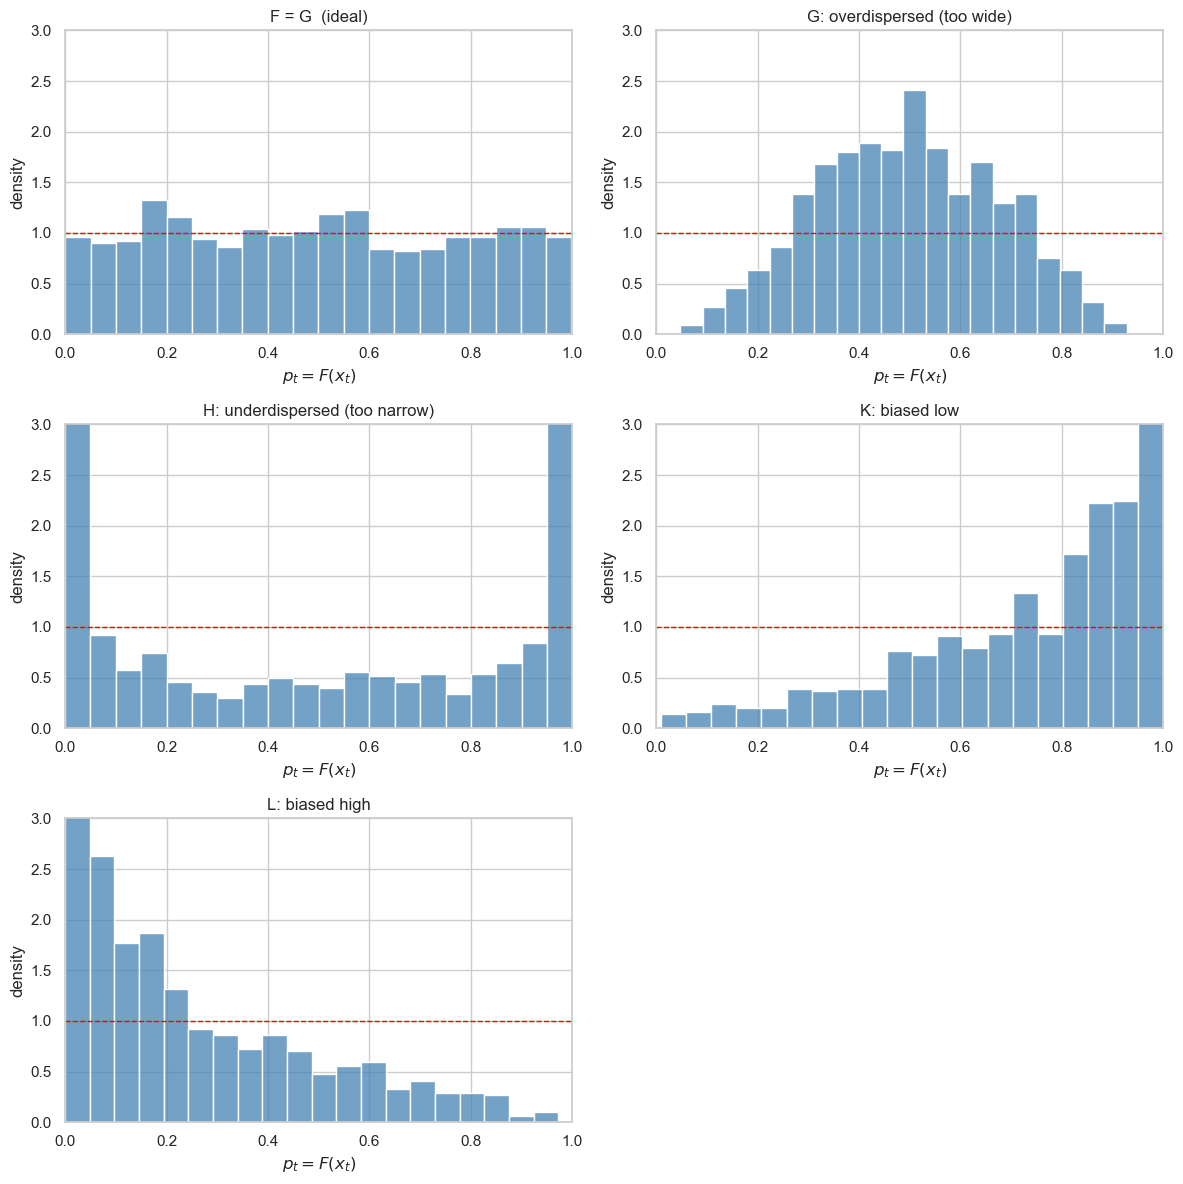

In [16]:
n_bins = 20

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, (label, p) in zip(axes, pits.items()):
    sns.histplot(p, bins=n_bins, stat="density", color="steelblue", ax=ax)
    ax.axhline(1.0, color="red", ls="--", lw=1)
    ax.set(title=label, xlabel=r"$p_t = F(x_t)$", ylabel="density",
           xlim=(0, 1), ylim=(0, 3))

axes[-1].axis("off")
plt.tight_layout()
plt.show()